# 03 Market Analysis

This notebook explores the cleaned job-posting dataset for the SkillMap project.

The goal is to compare UAE and Canadian early-career analytics/data roles by skill demand, salary availability, work mode, seniority, and experience expectations.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
CLEANED_JOBS_PATH = Path("../data/processed/cleaned_jobs.csv")
JOB_SKILLS_PATH = Path("../data/processed/job_skills.csv")
EXECUTIVE_SUMMARY_PATH = Path("../reports/executive_summary.md")

In [3]:
jobs_df = pd.read_csv(CLEANED_JOBS_PATH)
skills_df = pd.read_csv(JOB_SKILLS_PATH)

jobs_df.head()

,job_id,collection_date,country,city,job_title,company,source,job_url,employment_type,work_mode,...,years_experience_min,years_experience_max,education_requirement,description_short,skills_text,notes,salary_period,has_salary,experience_category,entry_level_with_high_experience
0,UAE_001,2026-05-20,UAE,Dubai,Product Data Analyst Intern,TikTok,GulfTalent,https://www.gulftalent.com/uae/jobs/product-da...,Full-time,NaN,...,NaN,NaN,NaN,Internship analyzing product performance trend...,"SQL, Excel, Tableau, Data Visualization, Dashb...",Internship requires at least 3-month commitment.,NaN,False,Not specified,False
1,UAE_002,2026-05-20,UAE,Dubai,Project Data Analyst Intern,CAGS Management Services DMCC,Bayt,https://www.bayt.com/en/uae/jobs/project-data-...,NaN,NaN,...,NaN,NaN,NaN,Internship supporting ERP implementation throu...,"Data Cleaning, Quality Assurance, Manual Testi...",Bayt notes the post was translated by AI.,NaN,False,Not specified,False
2,UAE_003,2026-05-20,UAE,Dubai,Data Analyst and Visual Content Designer (UAE ...,Genius HRTech Services,Bayt,https://www.bayt.com/en/uae/jobs/data-analyst-...,Full-time,NaN,...,1.0,3.0,Bachelor's degree / higher diploma,"Entry-level role analyzing HSE datasets, build...","Excel, Power BI, Dashboarding, Reporting, Data...",UAE nationals only.,NaN,True,1 year,False
3,UAE_004,2026-05-20,UAE,Dubai,Associate Data Analyst- UAE Nationals only,Delivery Hero SE,Bayt,https://www.bayt.com/en/uae/jobs/associate-dat...,NaN,NaN,...,2.0,3.0,"Bachelor's degree in Data Science, Statistics,...",Early-career analytics role supporting product...,"SQL, Excel, Tableau, Power BI, Looker, Python,...",UAE nationals only; early-career wording but r...,NaN,False,2 years,False
4,UAE_005,2026-05-20,UAE,Dubai,Associate Data Analyst,Bayut | dubizzle,GulfTalent,https://www.gulftalent.com/uae/jobs/associate-...,Full-time,NaN,...,2.0,3.0,NaN,"Associate strategy analytics role using SQL, E...","SQL, Excel, Dashboarding, Reporting, Data Visu...",NaN,NaN,False,2 years,False


In [4]:
print("Jobs dataset shape:", jobs_df.shape)
print("Skills dataset shape:", skills_df.shape)

Jobs dataset shape: (20, 24)
Skills dataset shape: (133, 7)


In [5]:
jobs_df["country"].value_counts()

country
UAE       10
Canada    10
Name: count, dtype: int64

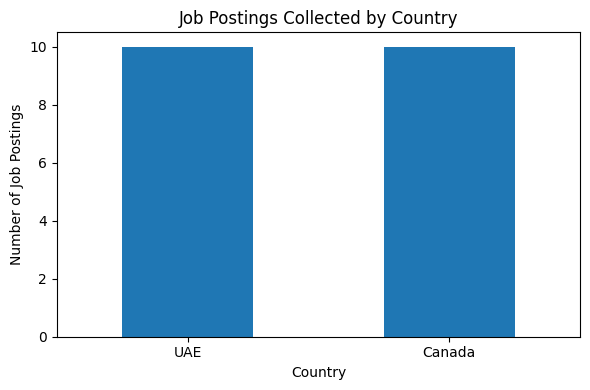

In [6]:
country_counts = jobs_df["country"].value_counts()

plt.figure(figsize=(6, 4))
country_counts.plot(kind="bar")
plt.title("Job Postings Collected by Country")
plt.xlabel("Country")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
seniority_counts = jobs_df["seniority"].value_counts(dropna=False)
seniority_counts

seniority
Internship     8
Junior         5
Entry-level    3
Associate      2
Co-op          2
Name: count, dtype: int64

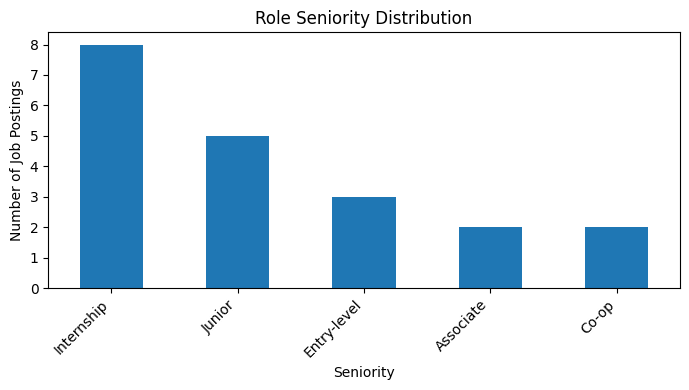

In [8]:
plt.figure(figsize=(7, 4))
seniority_counts.plot(kind="bar")
plt.title("Role Seniority Distribution")
plt.xlabel("Seniority")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [9]:
seniority_by_country = pd.crosstab(jobs_df["country"], jobs_df["seniority"])
seniority_by_country

seniority,Associate,Co-op,Entry-level,Internship,Junior
country,,,,,
Canada,0,2,0,4,4
UAE,2,0,3,4,1


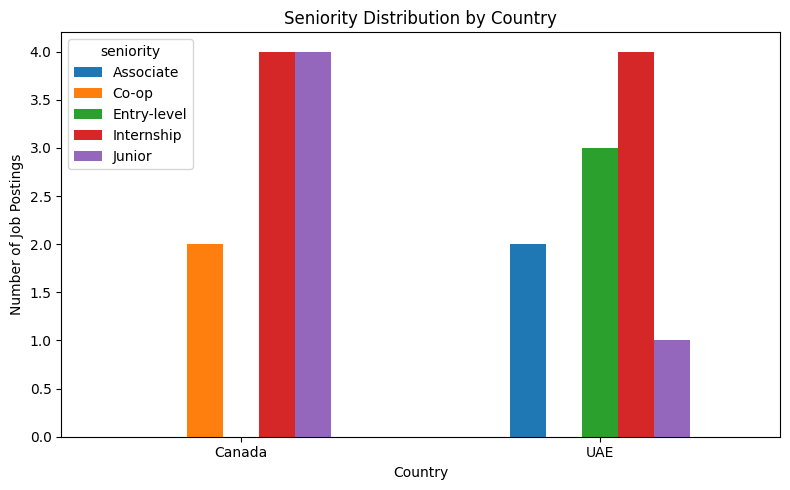

In [10]:
seniority_by_country.plot(kind="bar", figsize=(8, 5))
plt.title("Seniority Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
work_mode_counts = jobs_df["work_mode"].fillna("Not specified").value_counts()
work_mode_counts

work_mode
Not specified    9
Hybrid           6
On-site          4
Remote           1
Name: count, dtype: int64

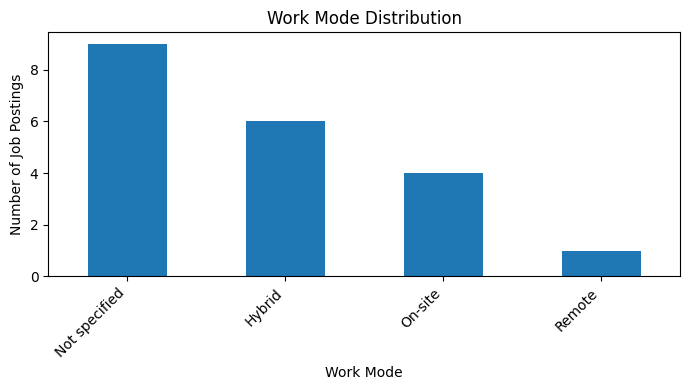

In [12]:
plt.figure(figsize=(7, 4))
work_mode_counts.plot(kind="bar")
plt.title("Work Mode Distribution")
plt.xlabel("Work Mode")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
work_mode_by_country = pd.crosstab(
    jobs_df["country"],
    jobs_df["work_mode"].fillna("Not specified")
)

work_mode_by_country

work_mode,Hybrid,Not specified,On-site,Remote
country,,,,
Canada,6,1,3,0
UAE,0,8,1,1


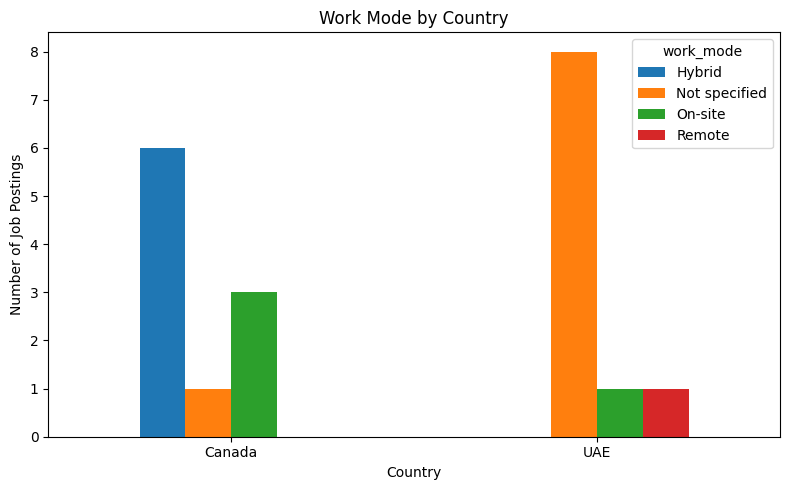

In [14]:
work_mode_by_country.plot(kind="bar", figsize=(8, 5))
plt.title("Work Mode by Country")
plt.xlabel("Country")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
salary_availability = jobs_df["has_salary"].value_counts()
salary_availability

has_salary
True     11
False     9
Name: count, dtype: int64

In [16]:
salary_disclosure_rate = jobs_df["has_salary"].mean() * 100
salary_disclosure_rate

np.float64(55.00000000000001)

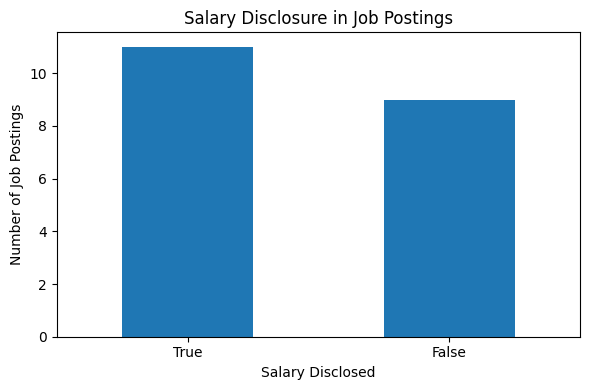

In [17]:
plt.figure(figsize=(6, 4))
salary_availability.plot(kind="bar")
plt.title("Salary Disclosure in Job Postings")
plt.xlabel("Salary Disclosed")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [18]:
salary_by_country = pd.crosstab(jobs_df["country"], jobs_df["has_salary"])
salary_by_country

has_salary,False,True
country,,
Canada,0,10
UAE,9,1


In [19]:
salary_by_country = salary_by_country.rename(columns={
    False: "Salary not disclosed",
    True: "Salary disclosed"
})

salary_by_country

has_salary,Salary not disclosed,Salary disclosed
country,,
Canada,0,10
UAE,9,1


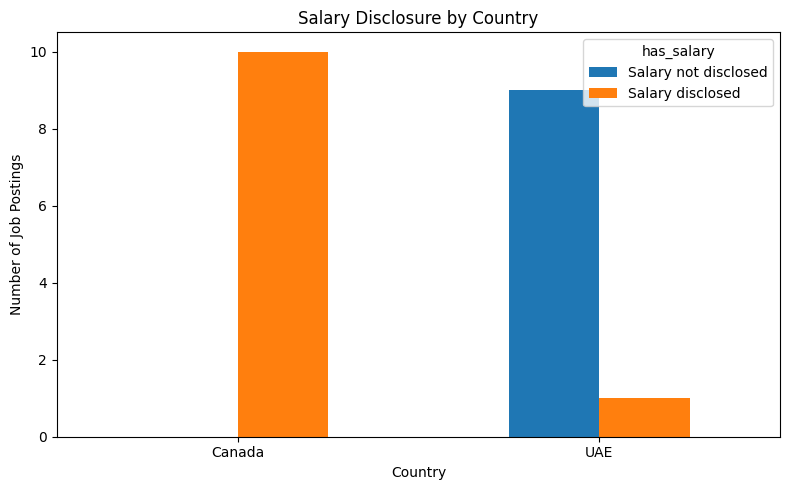

In [20]:
salary_by_country.plot(kind="bar", figsize=(8, 5))
plt.title("Salary Disclosure by Country")
plt.xlabel("Country")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [21]:
jobs_df[["job_id", "country", "job_title", "salary_min", "salary_max", "currency", "salary_period"]]

,job_id,country,job_title,salary_min,salary_max,currency,salary_period
0,UAE_001,UAE,Product Data Analyst Intern,NaN,NaN,NaN,NaN
1,UAE_002,UAE,Project Data Analyst Intern,NaN,NaN,NaN,NaN
2,UAE_003,UAE,Data Analyst and Visual Content Designer (UAE ...,14815.0,18519.0,AED,NaN
3,UAE_004,UAE,Associate Data Analyst- UAE Nationals only,NaN,NaN,NaN,NaN
4,UAE_005,UAE,Associate Data Analyst,NaN,NaN,NaN,NaN
5,UAE_006,UAE,Data Analyst Intern,NaN,NaN,NaN,NaN
6,UAE_007,UAE,Data Scientist / AI Engineer Intern,NaN,NaN,NaN,NaN
7,UAE_008,UAE,Associate Data Analyst,NaN,NaN,NaN,NaN
8,UAE_009,UAE,Jr. AI Business Analyst,NaN,NaN,NaN,NaN
9,UAE_010,UAE,Data Analyst – Performance Marketing,NaN,NaN,NaN,NaN


In [22]:
jobs_df["salary_period"].value_counts(dropna=False)

salary_period
NaN       10
Hourly     7
Annual     3
Name: count, dtype: int64

In [23]:
experience_counts = jobs_df["experience_category"].value_counts()
experience_counts

experience_category
Not specified                 7
0 years / student-friendly    5
1 year                        4
2 years                       4
Name: count, dtype: int64

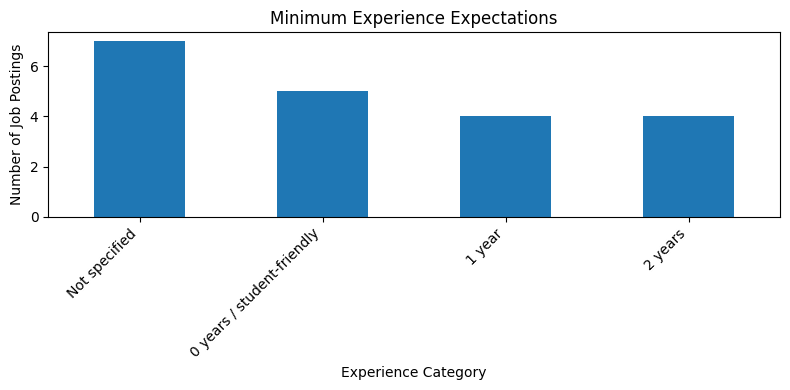

In [24]:
plt.figure(figsize=(8, 4))
experience_counts.plot(kind="bar")
plt.title("Minimum Experience Expectations")
plt.xlabel("Experience Category")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [25]:
high_experience_entry_roles = jobs_df[
    jobs_df["entry_level_with_high_experience"] == True
][
    [
        "job_id",
        "country",
        "job_title",
        "company",
        "seniority",
        "years_experience_min",
        "years_experience_max",
        "notes"
    ]
]

high_experience_entry_roles

,job_id,country,job_title,company,seniority,years_experience_min,years_experience_max,notes


In [26]:
num_high_experience_entry_roles = high_experience_entry_roles.shape[0]
num_high_experience_entry_roles

0

In [27]:
jobs_df["early_career_with_2plus_years"] = (
    jobs_df["seniority"].isin(["Entry-level", "Junior", "Associate"]) &
    (jobs_df["years_experience_min"] >= 2)
)

jobs_df[jobs_df["early_career_with_2plus_years"] == True][
    [
        "job_id",
        "country",
        "job_title",
        "company",
        "seniority",
        "years_experience_min",
        "years_experience_max",
        "notes"
    ]
]

,job_id,country,job_title,company,seniority,years_experience_min,years_experience_max,notes
3,UAE_004,UAE,Associate Data Analyst- UAE Nationals only,Delivery Hero SE,Associate,2.0,3.0,UAE nationals only; early-career wording but r...
4,UAE_005,UAE,Associate Data Analyst,Bayut | dubizzle,Associate,2.0,3.0,NaN
9,UAE_010,UAE,Data Analyst – Performance Marketing,Cheil Middle East & Africa,Entry-level,2.0,3.0,LinkedIn labels entry-level; posting asks for ...
15,CAN_006,Canada,Junior Data Analyst,Procom,Junior,2.0,3.0,Salary listed hourly; 6-month contract; hybrid...


In [28]:
top_skills = skills_df["skill"].value_counts().reset_index()
top_skills.columns = ["skill", "count"]

top_skills

,skill,count
0,Reporting,16
1,Stakeholder Communication,16
2,SQL,10
3,Technical Documentation,10
4,Data Visualization,9
5,Dashboarding,9
6,Excel,8
7,Power BI,8
8,Python,8
9,Presentation Skills,7


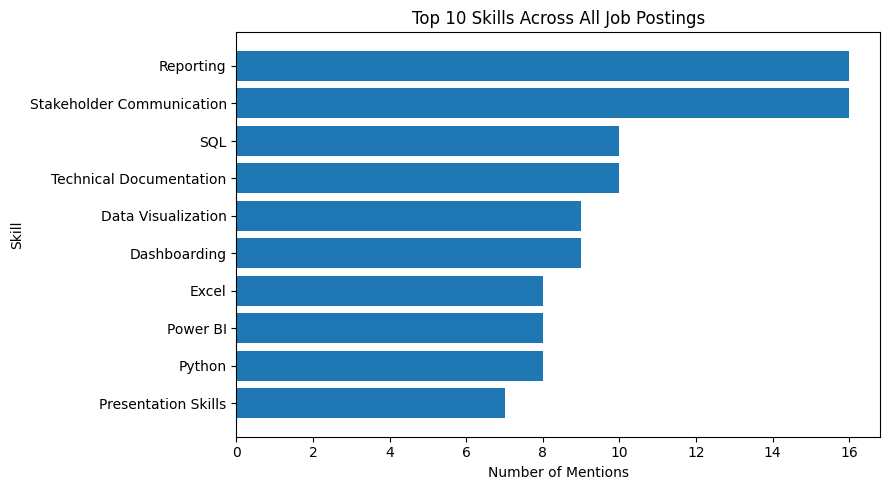

In [29]:
top_10_skills = top_skills.head(10)

plt.figure(figsize=(9, 5))
plt.barh(top_10_skills["skill"], top_10_skills["count"])
plt.title("Top 10 Skills Across All Job Postings")
plt.xlabel("Number of Mentions")
plt.ylabel("Skill")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [30]:
skills_by_country = (
    skills_df
    .groupby(["country", "skill"])
    .size()
    .reset_index(name="count")
    .sort_values(["country", "count"], ascending=[True, False])
)

skills_by_country

,country,skill,count
15,Canada,Reporting,8
17,Canada,Stakeholder Communication,8
20,Canada,Technical Documentation,8
12,Canada,Python,6
16,Canada,SQL,6
3,Canada,Data Visualization,4
10,Canada,Power BI,4
13,Canada,Quality Assurance,4
1,Canada,Dashboarding,3
2,Canada,Data Cleaning,3


In [31]:
uae_top_skills = (
    skills_by_country[skills_by_country["country"] == "UAE"]
    .sort_values("count", ascending=False)
    .head(10)
)

uae_top_skills

,country,skill,count
34,UAE,Reporting,8
36,UAE,Stakeholder Communication,8
25,UAE,Excel,7
22,UAE,Dashboarding,6
24,UAE,Data Visualization,5
29,UAE,Power BI,4
30,UAE,Presentation Skills,4
35,UAE,SQL,4
23,UAE,Data Cleaning,3
37,UAE,Tableau,3


In [32]:
canada_top_skills = (
    skills_by_country[skills_by_country["country"] == "Canada"]
    .sort_values("count", ascending=False)
    .head(10)
)

canada_top_skills

,country,skill,count
15,Canada,Reporting,8
17,Canada,Stakeholder Communication,8
20,Canada,Technical Documentation,8
12,Canada,Python,6
16,Canada,SQL,6
3,Canada,Data Visualization,4
10,Canada,Power BI,4
13,Canada,Quality Assurance,4
1,Canada,Dashboarding,3
2,Canada,Data Cleaning,3


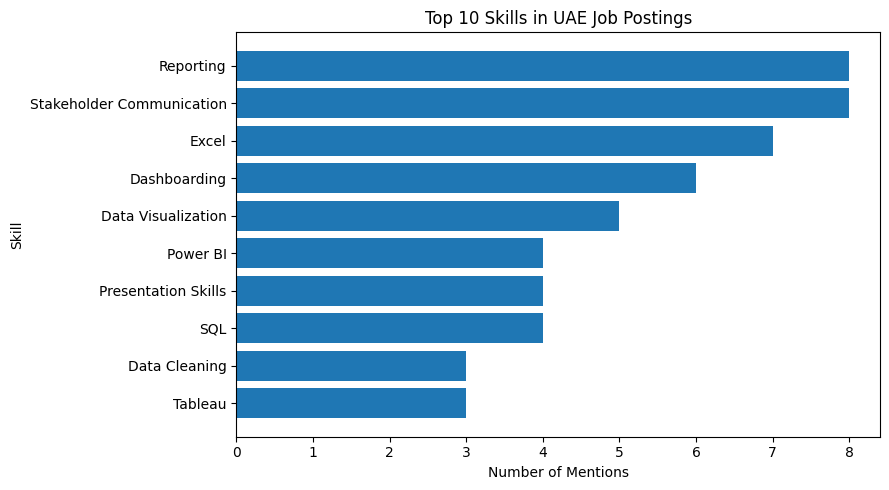

In [33]:
plt.figure(figsize=(9, 5))
plt.barh(uae_top_skills["skill"], uae_top_skills["count"])
plt.title("Top 10 Skills in UAE Job Postings")
plt.xlabel("Number of Mentions")
plt.ylabel("Skill")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

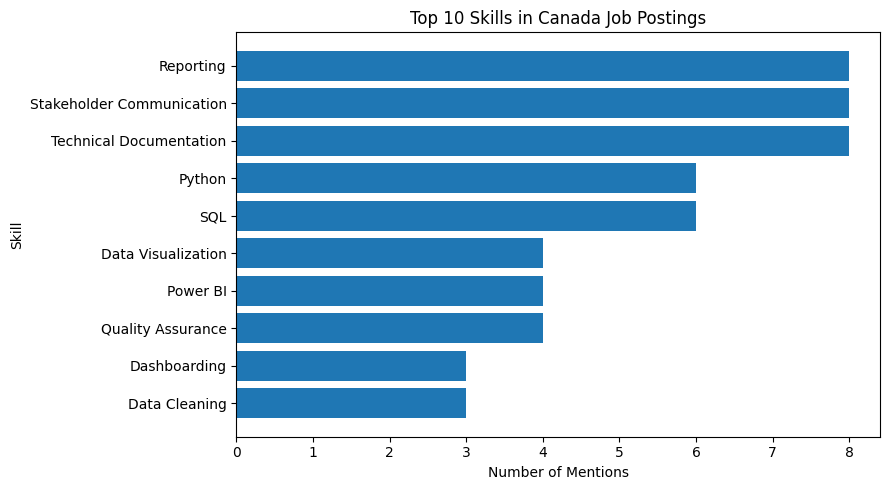

In [34]:
plt.figure(figsize=(9, 5))
plt.barh(canada_top_skills["skill"], canada_top_skills["count"])
plt.title("Top 10 Skills in Canada Job Postings")
plt.xlabel("Number of Mentions")
plt.ylabel("Skill")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [35]:
tool_skills = [
    "SQL",
    "Python",
    "Excel",
    "Power BI",
    "Tableau",
    "R",
    "Looker",
    "Azure",
    "AWS",
    "Google Cloud",
    "Snowflake"
]

tool_counts = (
    skills_df[skills_df["skill"].isin(tool_skills)]
    .groupby(["country", "skill"])
    .size()
    .reset_index(name="count")
    .sort_values(["country", "count"], ascending=[True, False])
)

tool_counts

,country,skill,count
5,Canada,Python,6
7,Canada,SQL,6
4,Canada,Power BI,4
0,Canada,Azure,1
1,Canada,Excel,1
2,Canada,Google Cloud,1
3,Canada,Looker,1
6,Canada,R,1
8,Canada,Tableau,1
9,UAE,Excel,7


In [36]:
tool_pivot = tool_counts.pivot_table(
    index="skill",
    columns="country",
    values="count",
    fill_value=0
)

tool_pivot

country,Canada,UAE
skill,,
Azure,1.0,0.0
Excel,1.0,7.0
Google Cloud,1.0,0.0
Looker,1.0,1.0
Power BI,4.0,4.0
Python,6.0,2.0
R,1.0,1.0
SQL,6.0,4.0
Tableau,1.0,3.0


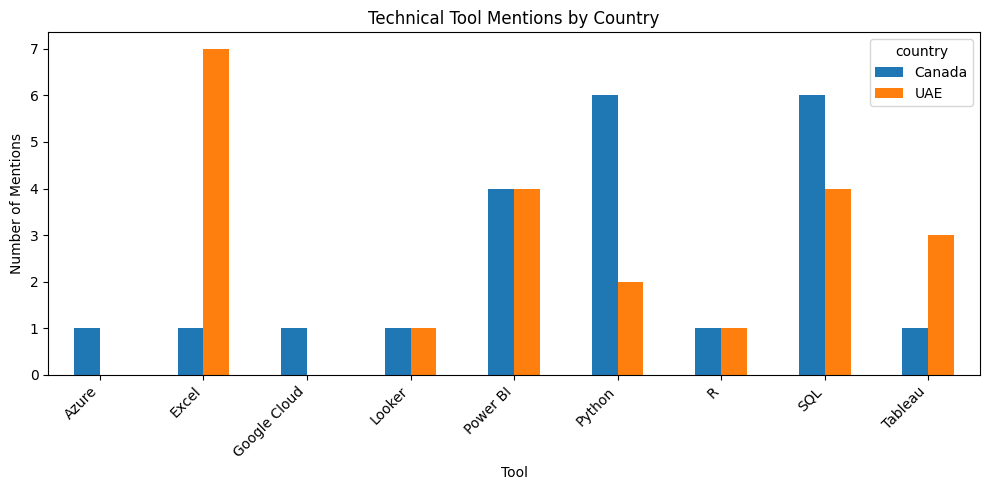

In [37]:
tool_pivot.plot(kind="bar", figsize=(10, 5))
plt.title("Technical Tool Mentions by Country")
plt.xlabel("Tool")
plt.ylabel("Number of Mentions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [40]:
total_jobs_by_country = jobs_df["country"].value_counts().to_dict()

skill_job_mentions = (
    skills_df
    .drop_duplicates(subset=["job_id", "country", "skill"])
    .groupby(["country", "skill"])
    .size()
    .reset_index(name="job_count")
)

skill_job_mentions["total_jobs_in_country"] = skill_job_mentions["country"].map(total_jobs_by_country)

skill_job_mentions["percentage_of_jobs"] = (
    skill_job_mentions["job_count"] / skill_job_mentions["total_jobs_in_country"] * 100
)

top_skills_by_country_pct = (
    skill_job_mentions
    .sort_values(["country", "percentage_of_jobs"], ascending=[True, False])
    .groupby("country")
    .head(10)
    .reset_index(drop=True)
)

top_skills_by_country_pct

,country,skill,job_count,total_jobs_in_country,percentage_of_jobs
0,Canada,Reporting,8,10,80.0
1,Canada,Stakeholder Communication,8,10,80.0
2,Canada,Technical Documentation,8,10,80.0
3,Canada,Python,6,10,60.0
4,Canada,SQL,6,10,60.0
5,Canada,Data Visualization,4,10,40.0
6,Canada,Power BI,4,10,40.0
7,Canada,Quality Assurance,4,10,40.0
8,Canada,Dashboarding,3,10,30.0
9,Canada,Data Cleaning,3,10,30.0


In [41]:
jobs_df["country"].value_counts()

country
UAE       10
Canada    10
Name: count, dtype: int64

In [42]:
skills_df["skill"].sort_values().unique()

<StringArray>
[                                                                                 'Azure',
                                                                          'Bug Reporting',
                                                                           'Dashboarding',
                                                                          'Data Cleaning',
                                                                     'Data Visualization',
                                                                                    'ETL',
                                                                                  'Excel',
                                                                           'Google Cloud',
                                                                                 'Looker',
                                                                       'Machine Learning',
                                                                         'Ma

In [43]:
country_order = ["UAE", "Canada"]

top_skills_by_country_pct["country"] = pd.Categorical(
    top_skills_by_country_pct["country"],
    categories=country_order,
    ordered=True
)

top_skills_by_country_pct = top_skills_by_country_pct.sort_values(
    ["country", "percentage_of_jobs"],
    ascending=[True, False]
)

top_skills_by_country_pct

,country,skill,job_count,total_jobs_in_country,percentage_of_jobs
10,UAE,Reporting,8,10,80.0
11,UAE,Stakeholder Communication,8,10,80.0
12,UAE,Excel,7,10,70.0
13,UAE,Dashboarding,6,10,60.0
14,UAE,Data Visualization,5,10,50.0
15,UAE,Power BI,4,10,40.0
16,UAE,Presentation Skills,4,10,40.0
17,UAE,SQL,4,10,40.0
18,UAE,Data Cleaning,3,10,30.0
19,UAE,Tableau,3,10,30.0


In [44]:
my_current_skills = [
    "Python",
    "Figma",
    "Manual Testing",
    "Quality Assurance",
    "Bug Reporting",
    "Technical Documentation",
    "Data Cleaning",
    "Stakeholder Communication",
    "Presentation Skills"
]

In [45]:
top_skill_list = top_skills["skill"].head(15).tolist()

skill_gap = pd.DataFrame({
    "skill": top_skill_list,
    "already_have": [skill in my_current_skills for skill in top_skill_list]
})

skill_gap

,skill,already_have
0,Reporting,False
1,Stakeholder Communication,True
2,SQL,False
3,Technical Documentation,True
4,Data Visualization,False
5,Dashboarding,False
6,Excel,False
7,Power BI,False
8,Python,True
9,Presentation Skills,True


In [46]:
missing_priority_skills = skill_gap[skill_gap["already_have"] == False]
missing_priority_skills

,skill,already_have
0,Reporting,False
2,SQL,False
4,Data Visualization,False
5,Dashboarding,False
6,Excel,False
7,Power BI,False
12,Tableau,False
14,Looker,False


In [47]:
total_jobs = jobs_df.shape[0]
uae_jobs = jobs_df[jobs_df["country"] == "UAE"].shape[0]
canada_jobs = jobs_df[jobs_df["country"] == "Canada"].shape[0]
salary_disclosed = jobs_df["has_salary"].sum()
salary_disclosure_pct = jobs_df["has_salary"].mean() * 100

top_skill_name = top_skills.iloc[0]["skill"]
top_skill_count = top_skills.iloc[0]["count"]

early_career_2plus_count = jobs_df["early_career_with_2plus_years"].sum()

print("Total jobs:", total_jobs)
print("UAE jobs:", uae_jobs)
print("Canada jobs:", canada_jobs)
print("Salary disclosed:", salary_disclosed)
print("Salary disclosure %:", round(salary_disclosure_pct, 1))
print("Top skill:", top_skill_name, "-", top_skill_count, "mentions")
print("Early-career roles requiring 2+ years:", early_career_2plus_count)

Total jobs: 20
UAE jobs: 10
Canada jobs: 10
Salary disclosed: 11
Salary disclosure %: 55.0
Top skill: Reporting - 16 mentions
Early-career roles requiring 2+ years: 4


In [48]:
summary_text = f"""# Executive Summary

## Project

SkillMap: UAE–Canada Tech Job Market Intelligence Dashboard

## Dataset

This analysis uses an initial sample of {total_jobs} early-career analytics, data, BI, product, and related technology job postings.

- UAE postings: {uae_jobs}
- Canada postings: {canada_jobs}

## Key Findings

1. The most frequently mentioned skill in the sample was **{top_skill_name}**, appearing {top_skill_count} times.

2. Salary information was disclosed in {salary_disclosed} out of {total_jobs} postings, giving a salary disclosure rate of {salary_disclosure_pct:.1f}%.

3. Several early-career roles required prior experience. In this sample, {early_career_2plus_count} roles labeled as entry-level, junior, or associate required at least 2 years of experience.

4. The skill demand pattern shows that analytics roles are not only technical. Reporting, dashboarding, communication, documentation, and stakeholder-facing skills appear frequently alongside tools such as SQL, Python, Excel, and Power BI.

## Limitations

This is a small manually collected sample of job postings and should be treated as directional rather than representative of the entire UAE or Canadian job market. Job descriptions vary by platform, and not all postings disclose salary, work mode, or experience requirements.

## Next Steps

The next phase will use SQL to query the cleaned dataset and prepare structured outputs for dashboard development.
"""

EXECUTIVE_SUMMARY_PATH.write_text(summary_text, encoding="utf-8")

print(f"Executive summary saved to: {EXECUTIVE_SUMMARY_PATH}")

Executive summary saved to: ..\reports\executive_summary.md


## Phase 4 Summary

This notebook explored the cleaned 20-row job posting dataset and compared UAE and Canada across job type, work mode, salary disclosure, experience expectations, and skill demand.

The analysis produced several early insights:

- The dataset is balanced between UAE and Canada.
- Salary disclosure varies across postings and must be interpreted carefully because salary periods differ.
- Several early-career roles still require prior experience.
- Skill demand combines technical tools with business-facing skills such as reporting, communication, documentation, and dashboarding.
- The extracted skills dataset is ready for SQL querying and dashboard development.

The next phase will focus on SQL analysis.